# Division-Plane Decoupling Analysis

Decouples the contributions of **rotation mean**, **rotation stdev**, and **y-offset**
to the cell-sorted NB-at-edge phenotype observed in calibrated WT simulations.

**Three experimental arms:**

| Arm | What varies | Conditions |
|---|---|---|
| Rotation mean (relrot) | divMean: 0 → 45 → 90° (relative rotation) | 4 conditions |
| Stdev | divStdev: 26 → 45 → 90° (absolute rotation, mean=0) | 3 conditions |
| Y-offset | yoffset: 88 → 50 (mean=0, stdev=26) | 2 conditions |

Baseline for all arms: `wt_divMean0Stdev26` (calibrated WT, absolute rotation, yoffset=88).

Only sim61 (NONE, VCV=1) and sim71 (NONE, VCV=0) are used throughout.

**Metrics:** `norm_het_frac` (spatial mixing), `exposed_frac` (NB perimeter exposure),
and composition metrics for supplement (n_pros, n_dpn).

---
## Section 0 — Setup

In [7]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [ ]:
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'pyproject.toml').exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('Could not find repo root')
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / 'src'))
from npa.sim_viz import render_raw, load_raw_snapshot_full

SWEEP_ROOT  = REPO_ROOT / 'data/sim/decoupling'
PROC_DIR    = REPO_ROOT / 'data/sim/processed_decoupling'

FIGURES_DIR = PROC_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Preprocess if NPZs don't exist yet
_npz_missing = not (PROC_DIR / 'sim_run_index.csv').exists()
if _npz_missing:
    import subprocess
    print('Running preprocess_sim.py ...')
    subprocess.run(
        ['uv', 'run', 'python', 'scripts/preprocess_sim.py',
         '--sweep-root', str(SWEEP_ROOT),
         '--out-dir',    str(PROC_DIR),
         '--sim-ids', 'vcv1_noreg', 'vcv0_noreg'],
        cwd=str(REPO_ROOT), check=True
    )
    print('Running extract_metrics.py ...')
    subprocess.run(
        ['uv', 'run', 'python', 'scripts/extract_metrics.py',
         '--kind', 'sim',
         '--sweep-root', str(SWEEP_ROOT),
         '--out-dir',    str(PROC_DIR),
         '--sim-ids', 'vcv1_noreg', 'vcv0_noreg'],
        cwd=str(REPO_ROOT), check=True
    )
    print('Running summarize_metrics.py ...')
    subprocess.run(
        ['uv', 'run', 'python', 'scripts/summarize_metrics.py',
         '--sim-metrics', str(PROC_DIR / 'sim_timepoint_metrics.csv'),
         '--exp-metrics',  str(REPO_ROOT / 'data/exp/processed/metrics.csv')],
        cwd=str(REPO_ROOT), check=True
    )

sim     = pd.read_csv(PROC_DIR / 'sim_metrics_last.csv')
run_idx = pd.read_csv(PROC_DIR / 'sim_run_index.csv', dtype=str)
run_idx['npz_row'] = run_idx['npz_row'].astype(int)

print('sim_metrics_last:', len(sim), 'rows')
print('Conditions found:', sorted(sim['condition'].unique()))

In [ ]:
# ── Condition registry ────────────────────────────────────────────────────
# Each arm is a list of dicts: {condition, label, color}
# The baseline (wt_divMean0Stdev26) appears in every arm as the left-most bar.

# Colours: warm = higher rotation / more stdev / different offset; cool = baseline/reference
_BASELINE_CLR = '#5b7fcc'   # blue
_RELROT_CLRS  = ['#4daf4a', '#f4a400', '#e0441a']  # relrot baseline, mean45, mean90
_STDEV_CLRS   = ['#8b70c0', '#9c6fb5', '#b55a9a', '#c94480', '#d43060']  # stdev 35→90
_YOFF_CLRS    = ['#8fa8c0', '#b5926a', '#cc7b4a']  # yoffset75, yoffset62, yoffset50

ARM_RELROT = [
    {'condition': 'wt_divMean0Stdev26',         'label': 'D0S26\n(baseline)', 'color': _BASELINE_CLR},
    {'condition': 'wt_divMean0Stdev26_relrot',  'label': 'D0S26\nrelrot',     'color': _RELROT_CLRS[0]},
    {'condition': 'wt_divMean45Stdev26_relrot', 'label': 'D45S26\nrelrot',    'color': _RELROT_CLRS[1]},
    {'condition': 'wt_divMean90Stdev26_relrot', 'label': 'D90S26\nrelrot',    'color': _RELROT_CLRS[2]},
]

ARM_STDEV = [
    {'condition': 'wt_divMean0Stdev26',  'label': 'D0S26\n(baseline)', 'color': _BASELINE_CLR},
    {'condition': 'wt_divMean0Stdev35',  'label': 'D0S35',             'color': _STDEV_CLRS[0]},
    {'condition': 'wt_divMean0Stdev45',  'label': 'D0S45',             'color': _STDEV_CLRS[1]},
    {'condition': 'wt_divMean0Stdev60',  'label': 'D0S60',             'color': _STDEV_CLRS[2]},
    {'condition': 'wt_divMean0Stdev75',  'label': 'D0S75',             'color': _STDEV_CLRS[3]},
    {'condition': 'wt_divMean0Stdev90',  'label': 'D0S90',             'color': _STDEV_CLRS[4]},
]

ARM_YOFFSET = [
    {'condition': 'wt_divMean0Stdev26',          'label': 'D0S26\n(baseline)', 'color': _BASELINE_CLR},
    {'condition': 'wt_divMean0Stdev26_yoffset75', 'label': 'D0S26\nyoffset75', 'color': _YOFF_CLRS[0]},
    {'condition': 'wt_divMean0Stdev26_yoffset62', 'label': 'D0S26\nyoffset62', 'color': _YOFF_CLRS[1]},
    {'condition': 'wt_divMean0Stdev26_yoffset50', 'label': 'D0S26\nyoffset50', 'color': _YOFF_CLRS[2]},
]

ALL_ARMS = [
    ('Rotation mean (relrot)', ARM_RELROT),
    ('Stdev sweep',            ARM_STDEV),
    ('Y-offset',               ARM_YOFFSET),
]

ALL_CONDITIONS = list({
    e['condition'] for arm_entries in [ARM_RELROT, ARM_STDEV, ARM_YOFFSET] for e in arm_entries
})

SIM_IDS = ['vcv1_noreg', 'vcv0_noreg']   # NONE, VCV=1 and NONE, VCV=0
SIM_LABELS = {'sim61': 'sim61 (NONE, VCV=1)', 'sim71': 'sim71 (NONE, VCV=0)'}

METRICS = ['lin_area_vox', 'n_pros', 'n_dpn', 'dpn_area_vox', 'avg_dpn_area_vox']
METRIC_LABELS = {
    'lin_area_vox':     'Lineage area (vox)',
    'n_pros':           'Pros count',
    'n_dpn':            'NB count',
    'dpn_area_vox':     'Total NB area (vox)',
    'avg_dpn_area_vox': 'Avg NB area (vox/cell)',
}

# Filter sim dataframe to only the conditions and sim_ids used here
sim = sim[
    sim['condition'].isin(ALL_CONDITIONS) &
    sim['sim_id'].isin(SIM_IDS)
].copy()

# Verify all expected conditions are present
present = set(sim['condition'].unique())
for arm_name, arm_entries in ALL_ARMS:
    print(f'\n{arm_name}:')
    for e in arm_entries:
        flag = '✓' if e['condition'] in present else '✗ MISSING'
        print(f'  {flag}  {e["condition"]}')

In [ ]:
import npa.sim_viz as _sim_viz_mod
_sim_viz_mod.POP2_COLOR = '#4a96b7'
_sim_viz_mod.POP3_COLOR = '#00a6a4'


# ── Physical scale ────────────────────────────────────────────────────────
# pixels_per_um = canvas_size / sim_space_um
# Yoffset sims: 600×600 µm space on 200×200 px canvas → 200/600 px/µm
# All other conditions default to _DEFAULT_PIXELS_PER_UM.
# Set _DEFAULT_PIXELS_PER_UM to canvas_size / sim_space_um for baseline sims.
PIXELS_PER_UM = {
    'wt_divMean0Stdev26_yoffset50': 200 / 600,
    'wt_divMean0Stdev26_yoffset62': 200 / 600,
    'wt_divMean0Stdev26_yoffset75': 200 / 600,
}
_DEFAULT_PIXELS_PER_UM = 1.0   # ← set to canvas_size / sim_space_um for baseline sims
SCALE_BAR_UM = 20              # ← width of scale bar label; adjust to taste
# ─────────────────────────────────────────────────────────────────────────


def heterotypic_contact_fraction(geo):
    nb    = geo[..., 0] > 0
    nonnb = geo[..., 1] > 0
    occ   = nb | nonnb
    n_occ = int(occ.sum())
    if n_occ == 0:
        return dict(het_frac=np.nan, norm_het_frac=np.nan,
                    p_nb=np.nan, p_nonnb=np.nan, n_occupied=0)
    p_nb_val    = float(nb[occ].mean())
    p_nonnb_val = float(nonnb[occ].mean())
    both_h = occ[:, :-1] & occ[:, 1:]
    het_h  = both_h & (nb[:, :-1] ^ nb[:, 1:])
    both_v = occ[:-1, :] & occ[1:, :]
    het_v  = both_v & (nb[:-1, :] ^ nb[1:, :])
    total = int(both_h.sum()) + int(both_v.sum())
    het   = int(het_h.sum()) + int(het_v.sum())
    if total == 0:
        return dict(het_frac=np.nan, norm_het_frac=np.nan,
                    p_nb=p_nb_val, p_nonnb=p_nonnb_val, n_occupied=n_occ)
    hf       = het / total
    expected = 2.0 * p_nb_val * p_nonnb_val
    norm_hf  = (hf / expected) if expected > 0 else np.nan
    return dict(het_frac=hf, norm_het_frac=norm_hf,
                p_nb=p_nb_val, p_nonnb=p_nonnb_val, n_occupied=n_occ)


def nb_exposure_fraction(geo):
    nb    = geo[..., 0] > 0
    nonnb = geo[..., 1] > 0
    emp   = ~(nb | nonnb)
    n_exposed = n_contact = 0
    for nb_edge, emp_side, nonnb_side in [
        (nb[:, :-1] & ~nb[:, 1:],  emp[:, 1:],  nonnb[:, 1:]),
        (nb[:, 1:]  & ~nb[:, :-1], emp[:, :-1], nonnb[:, :-1]),
        (nb[:-1, :] & ~nb[1:, :],  emp[1:, :],  nonnb[1:, :]),
        (nb[1:, :]  & ~nb[:-1, :], emp[:-1, :], nonnb[:-1, :]),
    ]:
        n_exposed += int((nb_edge & emp_side).sum())
        n_contact += int((nb_edge & nonnb_side).sum())
    n_perimeter = n_exposed + n_contact
    if n_perimeter == 0:
        return dict(exposed_frac=np.nan, n_exposed=0, n_contact=0, n_perimeter=0)
    return dict(exposed_frac=n_exposed / n_perimeter,
                n_exposed=n_exposed, n_contact=n_contact, n_perimeter=n_perimeter)


def percentile_run_id(condition, sim_id, metric, pct):
    sub = sim[(sim['condition'] == condition) & (sim['sim_id'] == sim_id)].dropna(subset=[metric])
    if sub.empty:
        return None
    threshold = np.percentile(sub[metric], pct)
    idx = (sub[metric] - threshold).abs().idxmin()
    return str(sub.loc[idx, 'run_id']).zfill(4)


def draw_lineage(condition, sim_id, run_id, title='', ax=None):
    run_id = str(run_id).zfill(4)
    match = run_idx[
        (run_idx['condition'] == condition) &
        (run_idx['sim_id']    == sim_id) &
        (run_idx['run_id']    == run_id)
    ]
    if match.empty:
        raise ValueError(f'run_index missing: {condition} {sim_id} {run_id}')
    r = match.iloc[0]
    geo_raw, lmap = load_raw_snapshot_full(
        REPO_ROOT / r['cells_path'], REPO_ROOT / r['locs_path']
    )
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    _sim_viz_mod.render_raw(geo_raw, label_map=lmap, ax=ax, title=title)
    ax.axis('off')
    ppu = PIXELS_PER_UM.get(condition, _DEFAULT_PIXELS_PER_UM)
    _sim_viz_mod.add_scale_bar(ax, pixels_per_um=ppu, length_um=SCALE_BAR_UM)
    return ax


def _boxplot_arm(ax, arm_entries, data_df, metric, sim_id,
                 annotate=True, box_w=0.5):
    """Draw one arm's worth of box plots onto ax. Returns positions."""
    positions = list(range(len(arm_entries)))
    for xi, entry in enumerate(arm_entries):
        runs = data_df[
            (data_df['condition'] == entry['condition']) &
            (data_df['sim_id']    == sim_id)
        ][metric].dropna()
        if runs.empty:
            continue
        bp = ax.boxplot(
            [runs], positions=[xi], widths=box_w,
            patch_artist=True,
            medianprops={'color': 'black', 'linewidth': 1.5},
            whiskerprops={'linewidth': 0.8},
            capprops={'linewidth': 0.8},
            flierprops={'marker': 'o', 'markersize': 2, 'linestyle': 'none'},
            manage_ticks=False, zorder=2,
        )
        bp['boxes'][0].set_facecolor(entry['color'])
        bp['boxes'][0].set_alpha(0.82)
        if annotate:
            med       = float(np.median(runs))
            upper_cap = bp['caps'][1].get_ydata()[0]
            ax.text(xi, upper_cap, f'{med:.4f}',
                    ha='center', va='bottom', fontsize=6, rotation=90)
    ax.set_xticks(positions)
    ax.set_xticklabels([e['label'] for e in arm_entries], fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlim(-0.6, len(arm_entries) - 0.4)
    return positions

---
## Section 1 — Compute Spatial Metrics from NPZs

Computes `norm_het_frac` and `exposed_frac` for all 7 conditions × sim61 + sim71.
Results are cached to CSV so this only runs once.

In [11]:
_SPATIAL_CSV = PROC_DIR / 'spatial_metrics.csv'

if _SPATIAL_CSV.exists():
    spatial_df = pd.read_csv(_SPATIAL_CSV)
    print(f'Loaded cached spatial_metrics.csv ({len(spatial_df)} rows)')
else:
    records = []
    sub_idx = run_idx[
        run_idx['condition'].isin(ALL_CONDITIONS) &
        run_idx['sim_id'].isin(SIM_IDS)
    ]
    for npz_path_str, group in sub_idx.groupby('npz_path'):
        with np.load(REPO_ROOT / npz_path_str) as _d:
            _geo_all = _d['geo']
        for _, row in group.iterrows():
            geo_i  = _geo_all[int(row['npz_row'])]
            het    = heterotypic_contact_fraction(geo_i)
            exp    = nb_exposure_fraction(geo_i)
            records.append({
                'condition': row['condition'],
                'sim_id':    row['sim_id'],
                'run_id':    row['run_id'],
                **het,
                **{k: v for k, v in exp.items() if k not in het},
            })
    spatial_df = pd.DataFrame(records)
    spatial_df.to_csv(_SPATIAL_CSV, index=False)
    print(f'Computed and saved spatial_metrics.csv ({len(spatial_df)} rows)')

print()
print(spatial_df.groupby(['condition', 'sim_id'])[['norm_het_frac', 'exposed_frac']]
      .agg(['mean', 'median']).round(4).to_string())

Computed and saved spatial_metrics.csv (1000 rows)

                                    norm_het_frac         exposed_frac        
                                             mean  median         mean  median
condition                    sim_id                                           
wt_divMean0Stdev26           sim61         0.0228  0.0227       0.5928  0.5969
                             sim71         0.0230  0.0227       0.5853  0.5865
wt_divMean0Stdev26_relrot    sim61         0.0315  0.0296       0.4344  0.4733
                             sim71         0.0292  0.0262       0.4798  0.5284
wt_divMean0Stdev26_yoffset50 sim61         0.0499  0.0487       0.0252  0.0000
                             sim71         0.0507  0.0491       0.0040  0.0000
wt_divMean0Stdev35           sim61         0.0243  0.0243       0.5663  0.5748
                             sim71         0.0234  0.0223       0.5761  0.5912
wt_divMean0Stdev45           sim61         0.0264  0.0260       0.5238  0.5148


---
## Section 2 — Spatial Mixing and NB Exposure Charts

Each figure has 3 panels (one per arm) × 2 rows (sim61 / sim71).
The baseline condition appears as the left-most box in every arm panel.

**No y=1 reference line** for `norm_het_frac` — WT values are far below 1.

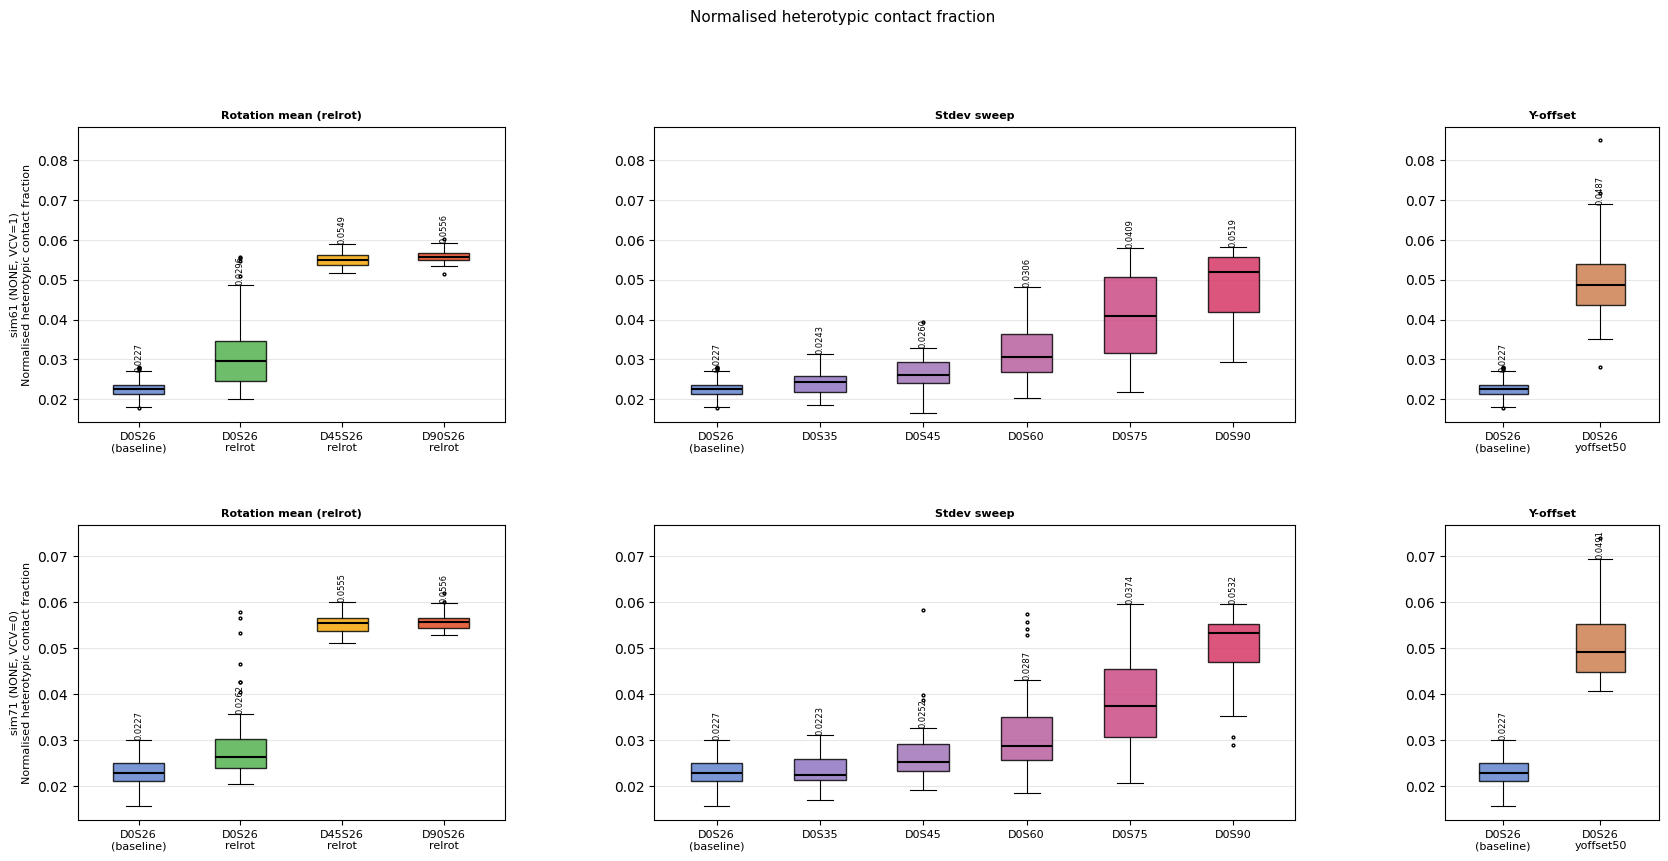

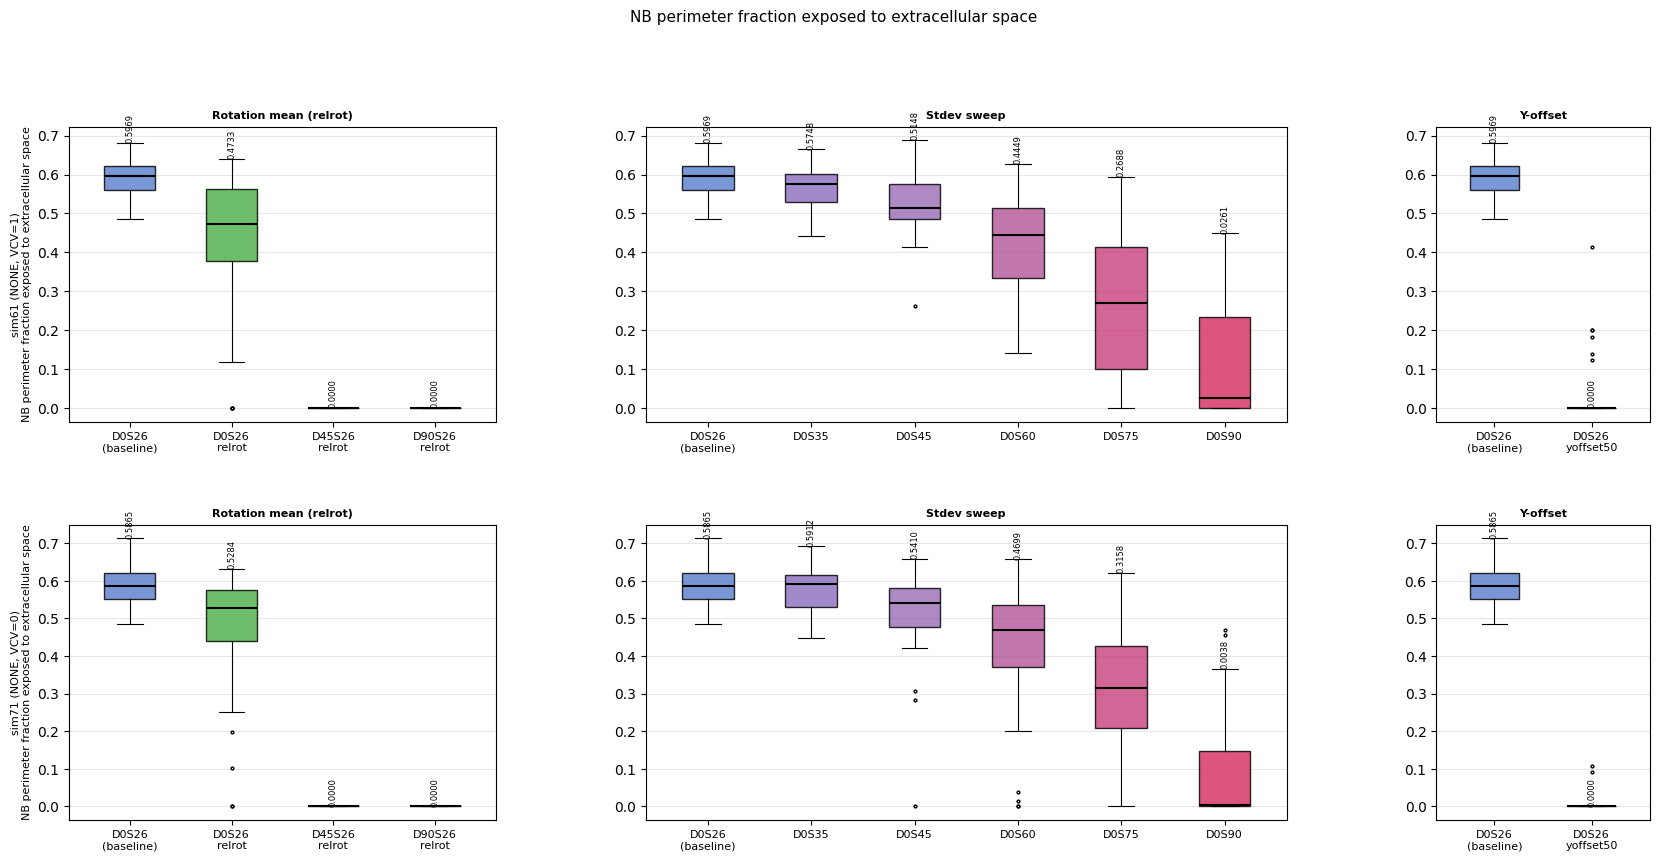

In [12]:
def _spatial_figure(metric, ylabel, fname, include_ref_line=False):
    arm_widths = [len(arm) for _, arm in ALL_ARMS]
    n_arms = len(ALL_ARMS)

    fig = plt.figure(figsize=(sum(arm_widths) * 1.6 + n_arms * 0.4, 9))
    outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.35)

    for ri, sim_id in enumerate(SIM_IDS):
        inner = gridspec.GridSpecFromSubplotSpec(
            1, n_arms, subplot_spec=outer[ri],
            wspace=0.35,
            width_ratios=arm_widths,
        )
        y_min = y_max = None

        axes = []
        for ci, (arm_name, arm_entries) in enumerate(ALL_ARMS):
            ax = fig.add_subplot(inner[ci])
            axes.append(ax)
            if include_ref_line:
                ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, zorder=1)
            _boxplot_arm(ax, arm_entries, spatial_df, metric, sim_id)
            ax.set_title(arm_name, fontsize=8, fontweight='bold')
            if ci == 0:
                ax.set_ylabel(f'{SIM_LABELS[sim_id]}\n{ylabel}', fontsize=8)
            # collect y range for shared scale within the row
            lo, hi = ax.get_ylim()
            y_min = lo if y_min is None else min(y_min, lo)
            y_max = hi if y_max is None else max(y_max, hi)

        # Share y-axis within each row
        for ax in axes:
            ax.set_ylim(y_min, y_max)

    fig.suptitle(ylabel, fontsize=11, y=1.01)
    fig.savefig(FIGURES_DIR / fname, dpi=120, bbox_inches='tight')
    plt.show()


_spatial_figure(
    metric='norm_het_frac',
    ylabel='Normalised heterotypic contact fraction',
    fname='norm_het_frac_decoupling.png',
    include_ref_line=False,   # WT values far below 1; omit to avoid blown-out y-axis
)

_spatial_figure(
    metric='exposed_frac',
    ylabel='NB perimeter fraction exposed to extracellular space',
    fname='exposed_frac_decoupling.png',
    include_ref_line=False,
)

---
## Section 3 — Supplement: Composition Metrics

Confirms that reparameterised yoffset50 runs end with comparable cell counts.
Shown for all 7 conditions; values near baseline indicate composition is controlled.

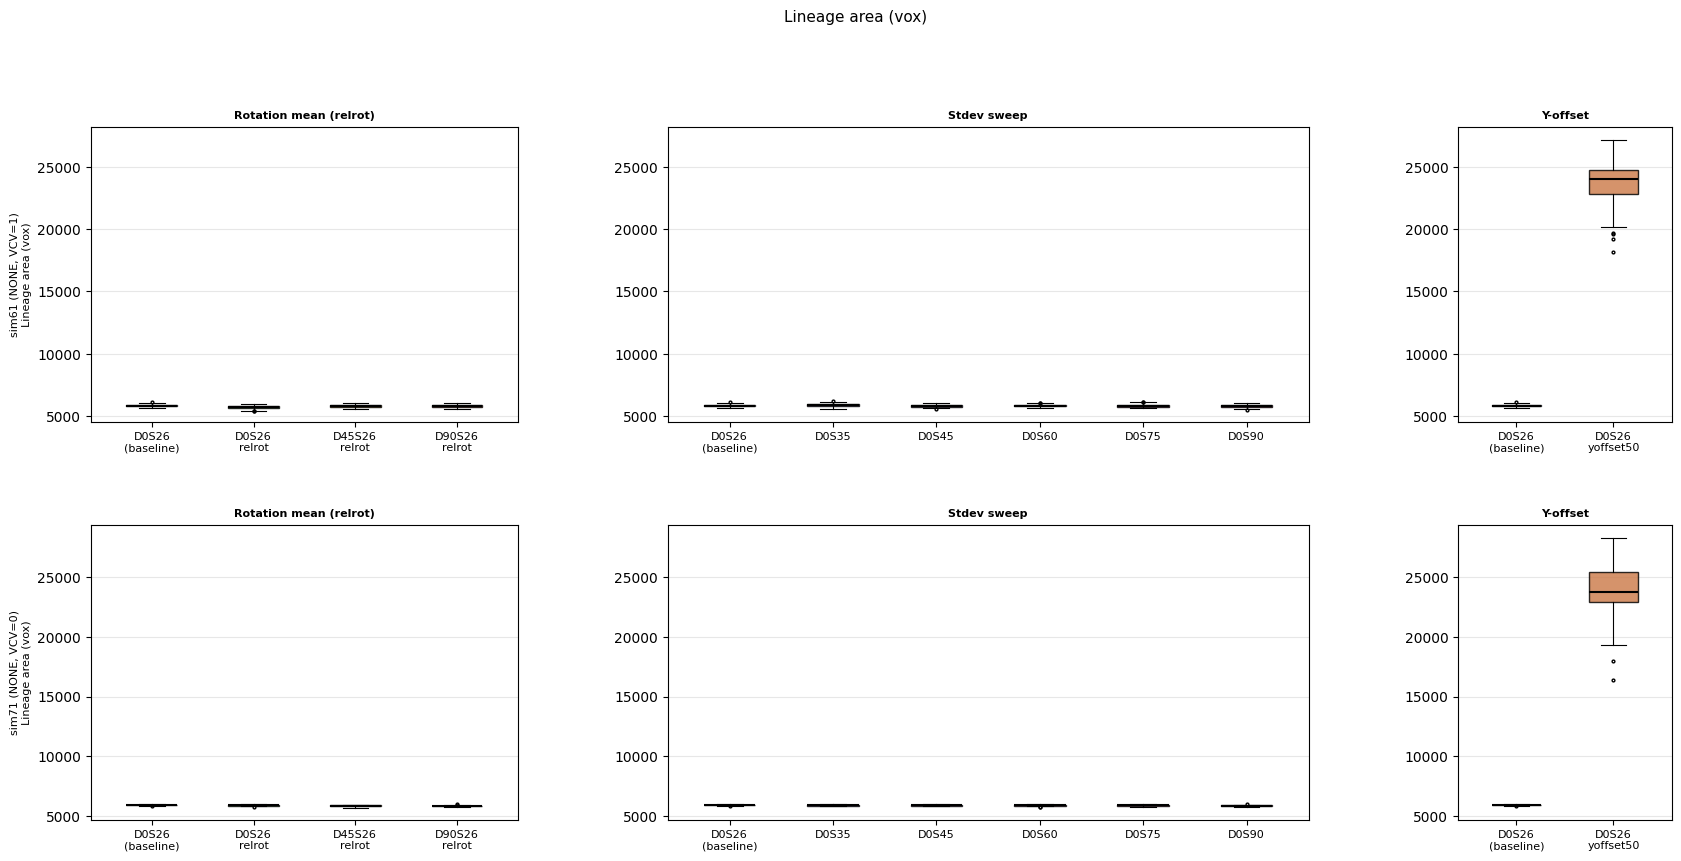

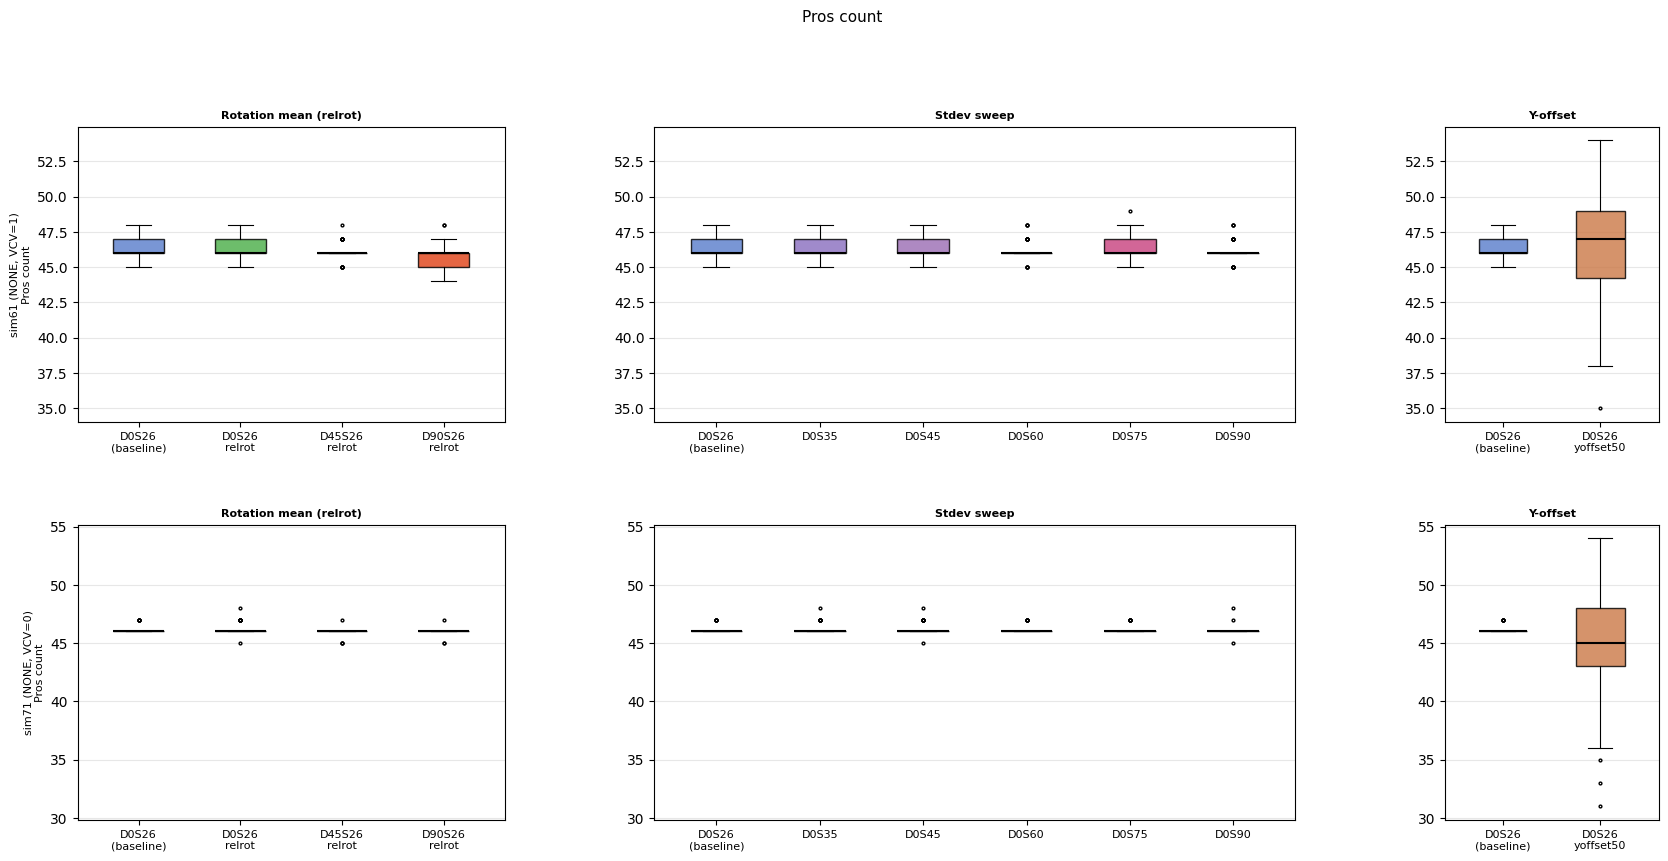

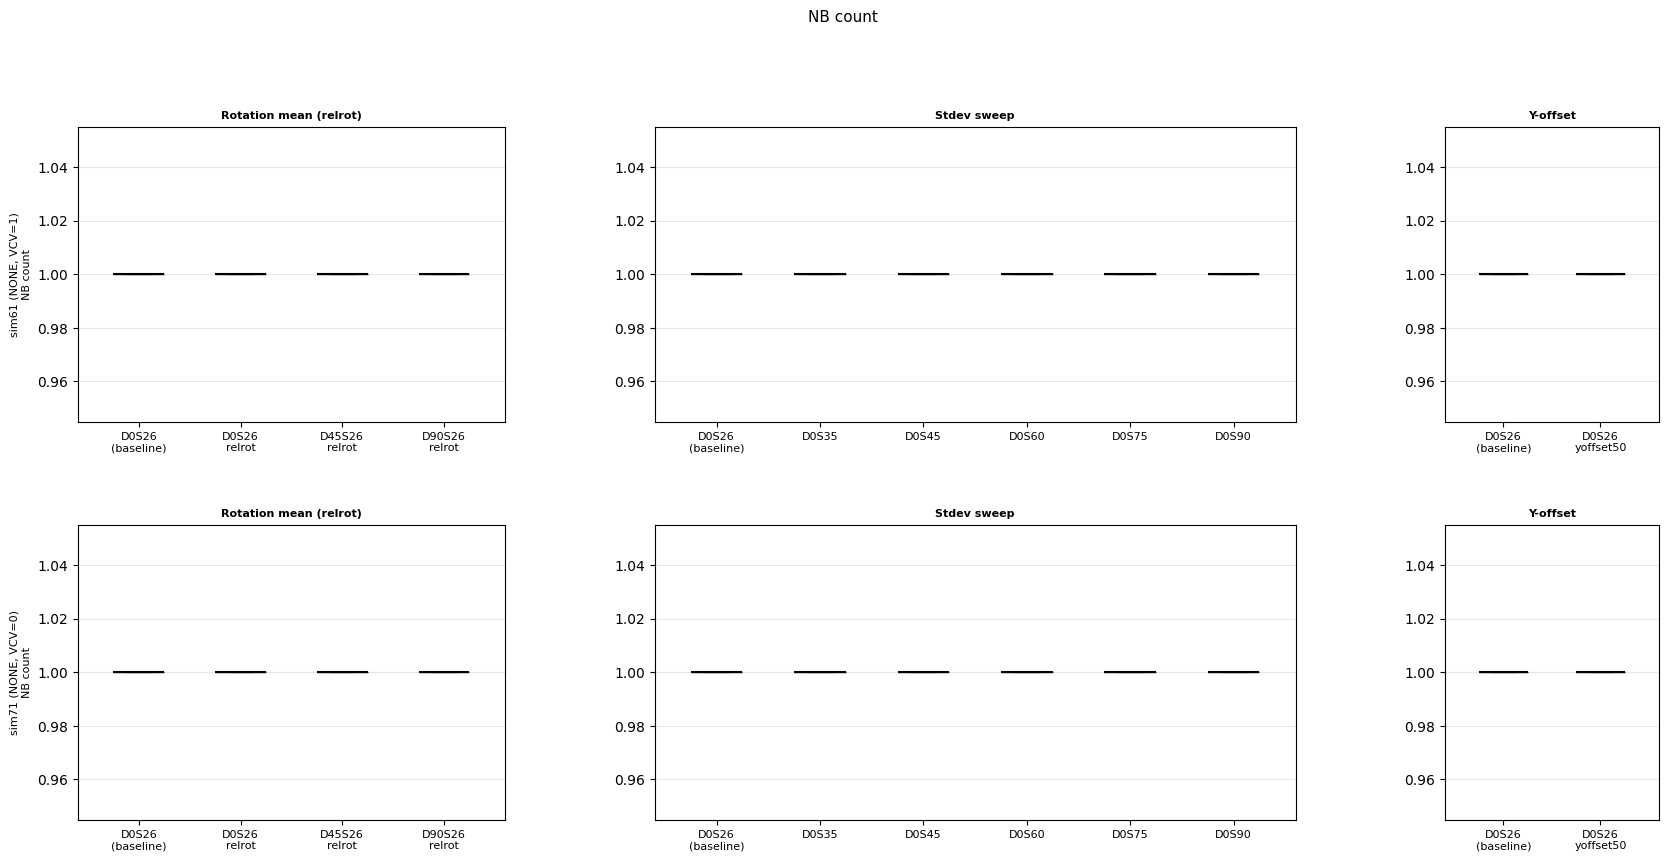

In [13]:
def _composition_figure(metric, ylabel, fname):
    arm_widths = [len(arm) for _, arm in ALL_ARMS]
    n_arms = len(ALL_ARMS)

    fig = plt.figure(figsize=(sum(arm_widths) * 1.6 + n_arms * 0.4, 9))
    outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.35)

    for ri, sim_id in enumerate(SIM_IDS):
        inner = gridspec.GridSpecFromSubplotSpec(
            1, n_arms, subplot_spec=outer[ri],
            wspace=0.35,
            width_ratios=arm_widths,
        )
        axes = []
        y_min = y_max = None
        for ci, (arm_name, arm_entries) in enumerate(ALL_ARMS):
            ax = fig.add_subplot(inner[ci])
            axes.append(ax)
            _boxplot_arm(ax, arm_entries, sim, metric, sim_id, annotate=False)
            ax.set_title(arm_name, fontsize=8, fontweight='bold')
            if ci == 0:
                ax.set_ylabel(f'{SIM_LABELS[sim_id]}\n{ylabel}', fontsize=8)
            lo, hi = ax.get_ylim()
            y_min = lo if y_min is None else min(y_min, lo)
            y_max = hi if y_max is None else max(y_max, hi)
        for ax in axes:
            ax.set_ylim(y_min, y_max)

    fig.suptitle(ylabel, fontsize=11, y=1.01)
    fig.savefig(FIGURES_DIR / fname, dpi=120, bbox_inches='tight')
    plt.show()


for metric in ['lin_area_vox', 'n_pros', 'n_dpn']:
    _composition_figure(
        metric=metric,
        ylabel=METRIC_LABELS[metric],
        fname=f'composition_{metric}_decoupling.png',
    )

---
## Section 4 — Example Lineages

10th, 50th, and 90th percentile lineages (by `lin_area_vox`) for each condition.
One figure per arm; rows = conditions within the arm; columns = [sim61 10th, sim61 50th,
sim61 90th | sim71 10th, sim71 50th, sim71 90th].

Colour key: **purple** = NB, **blue** = GMC, **teal** = neuron.

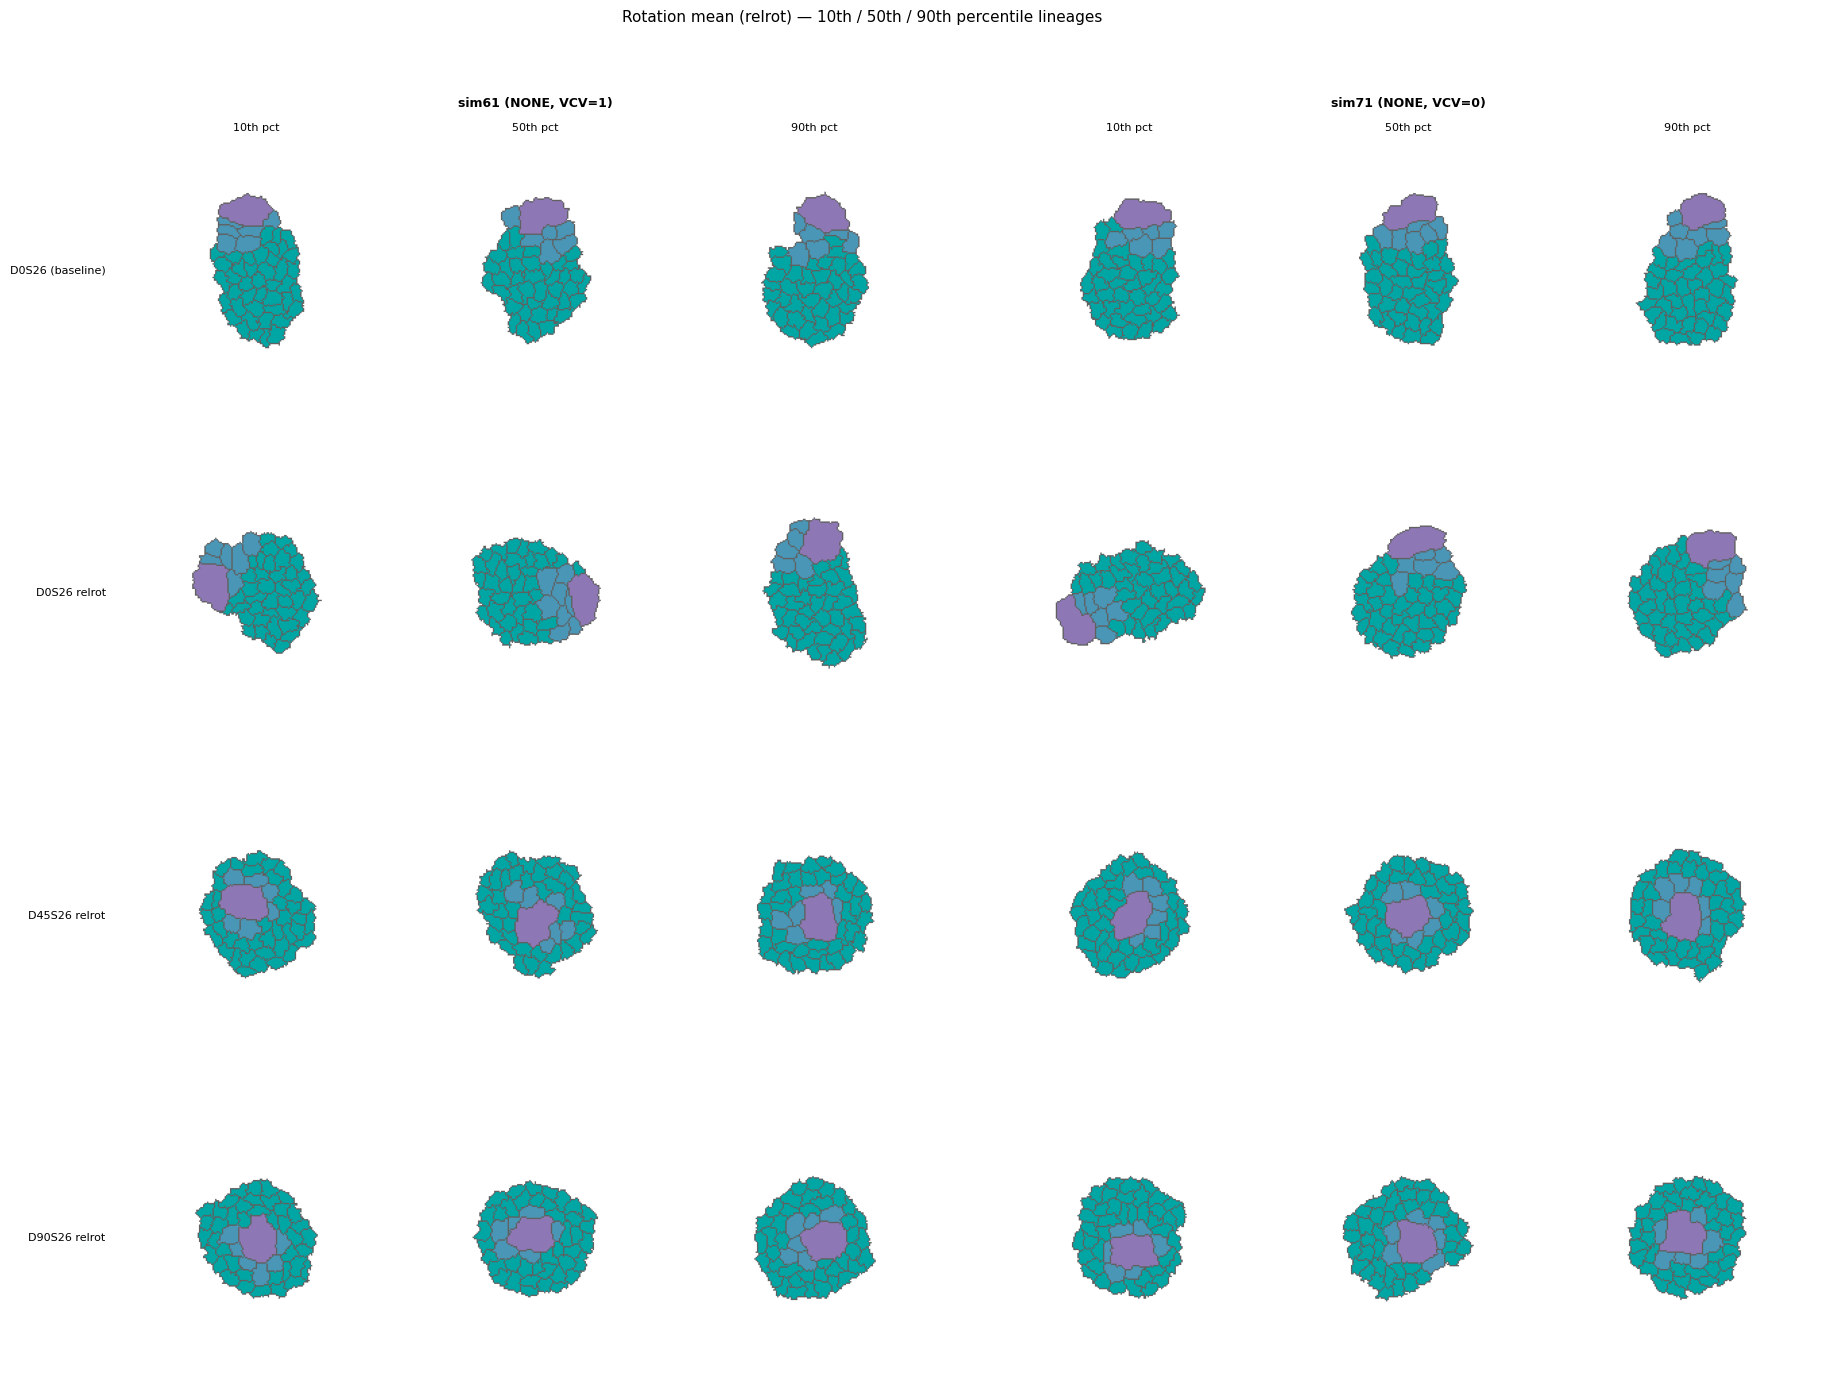

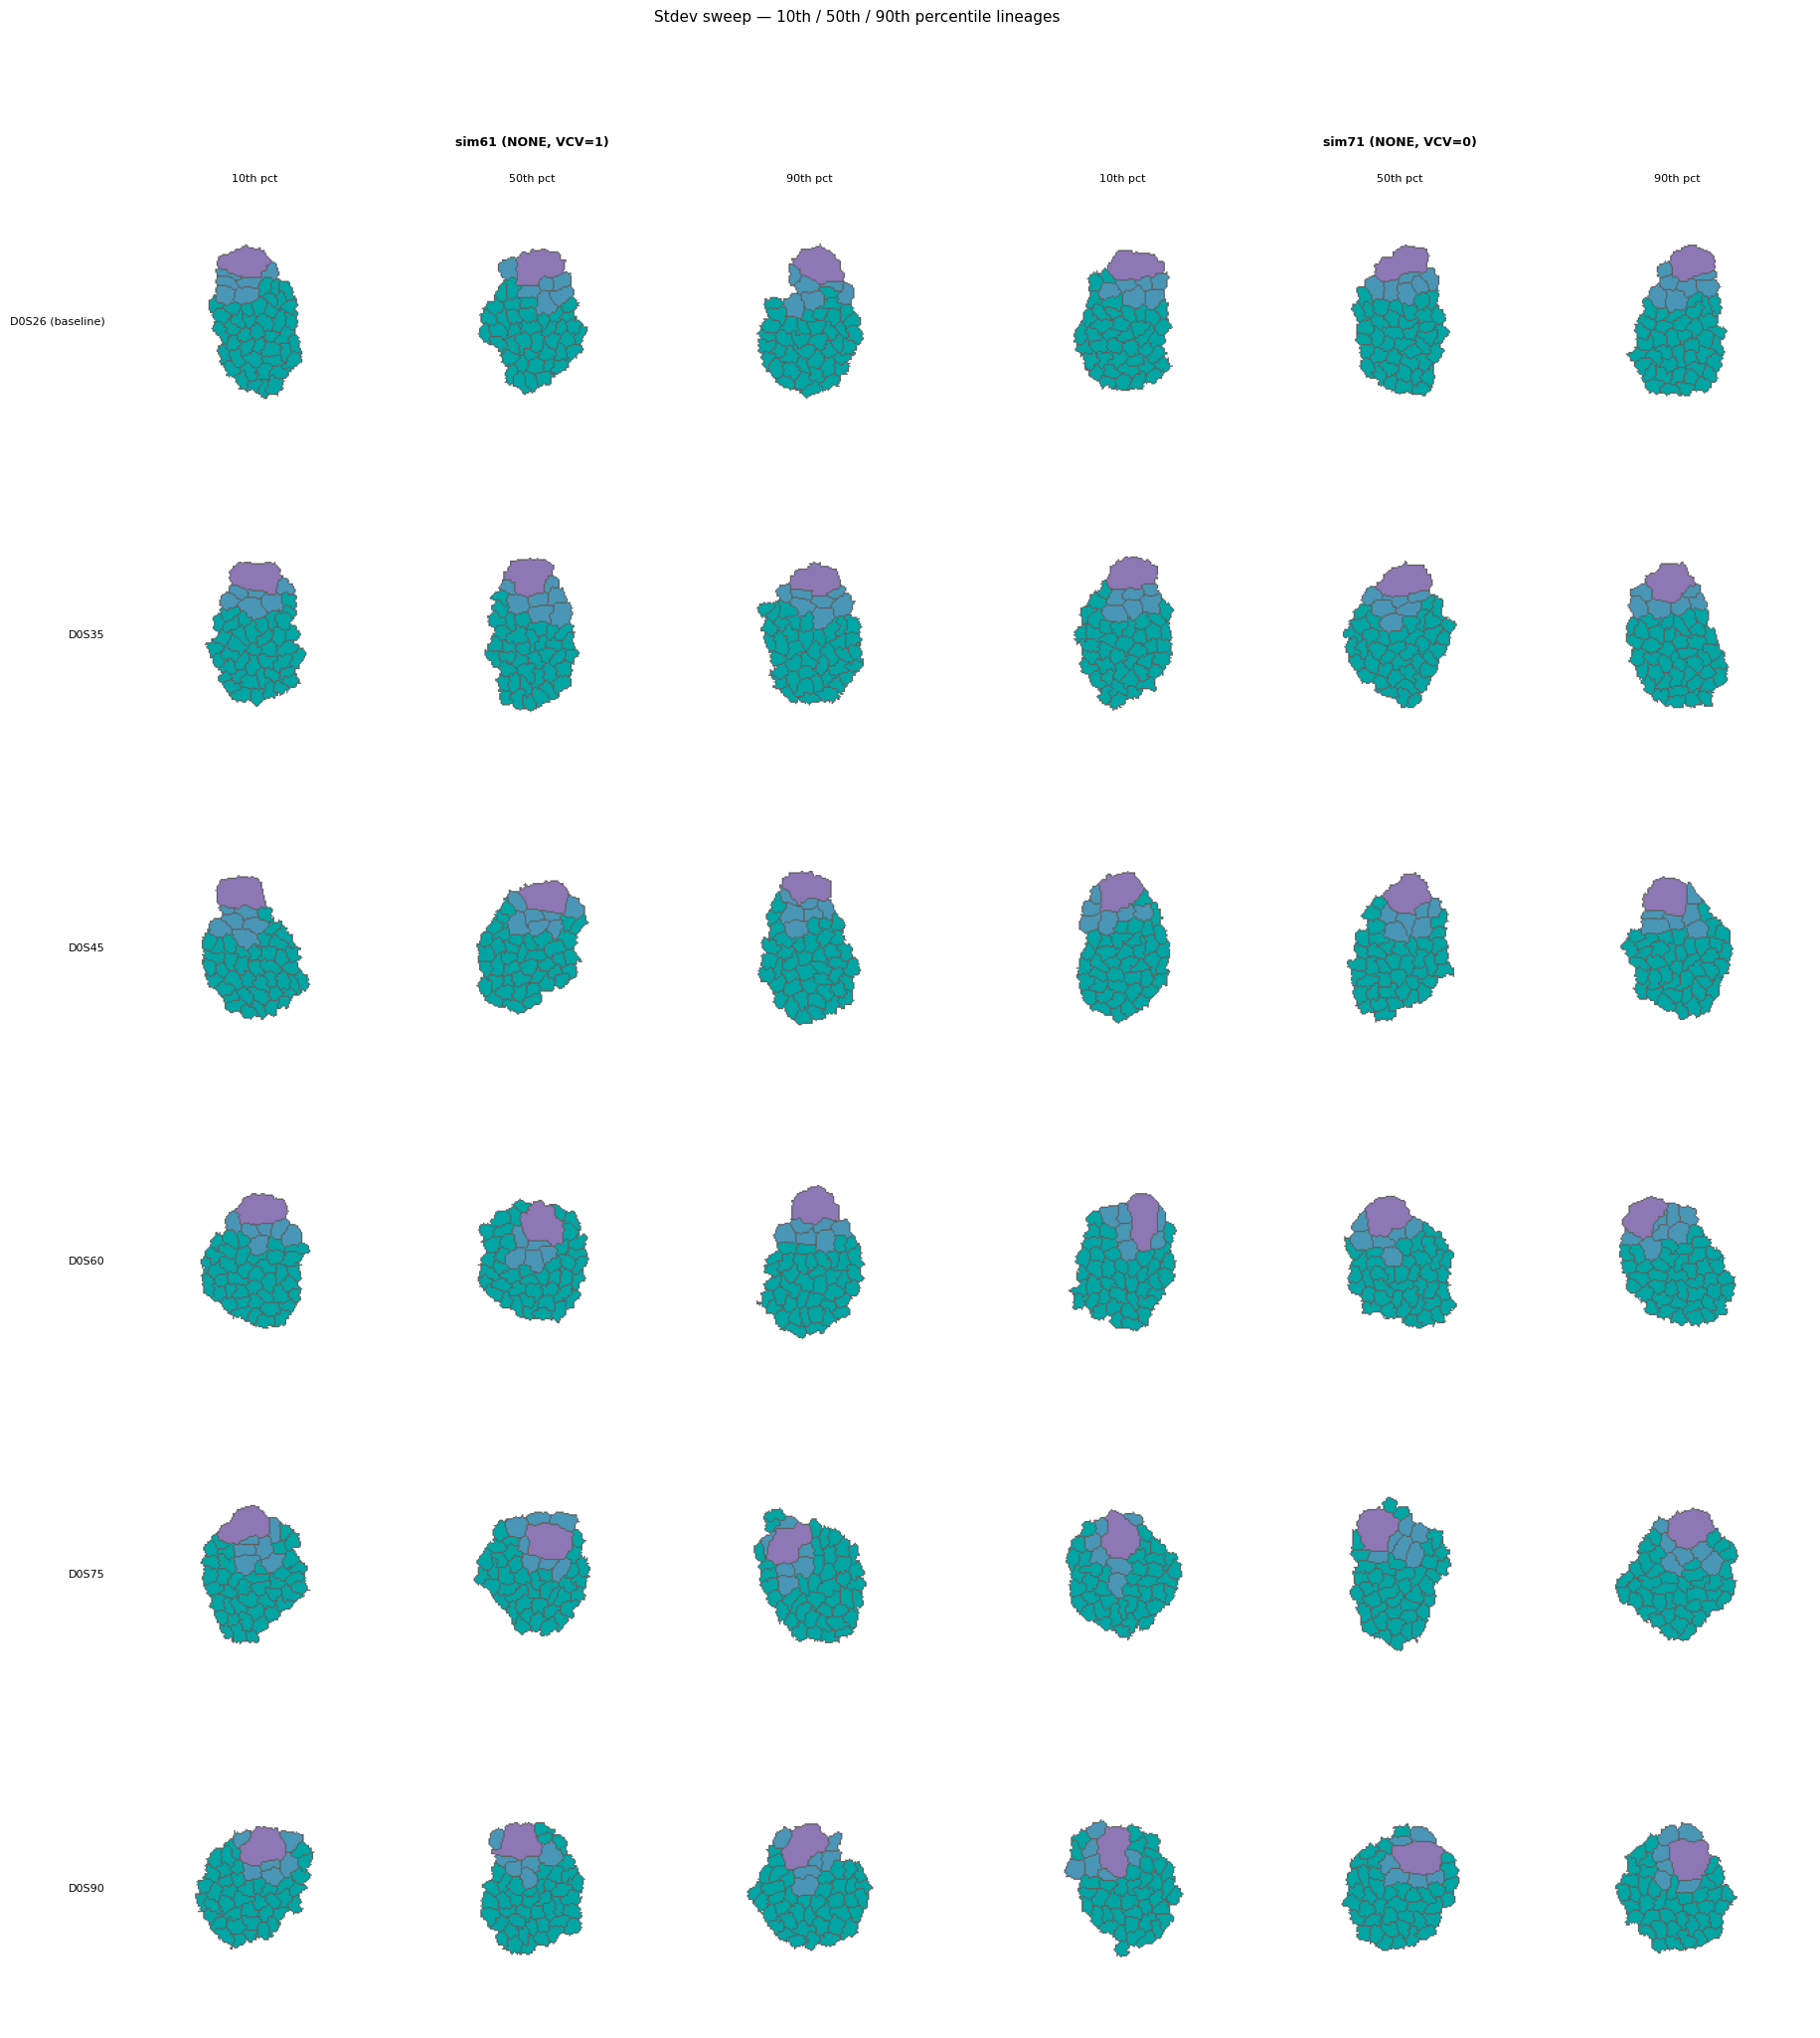

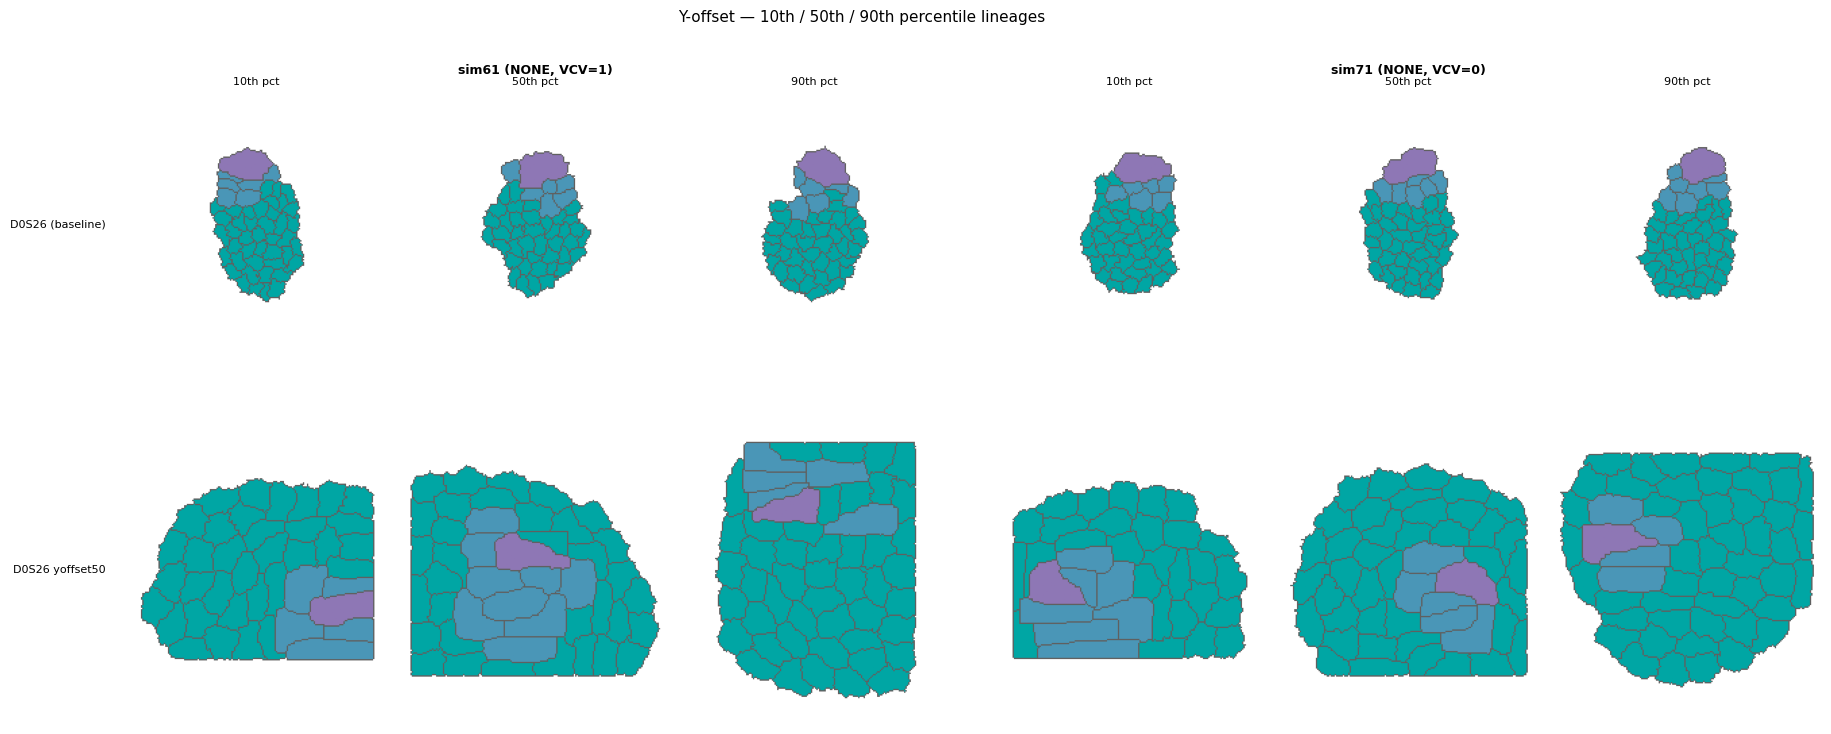

In [14]:
PERCENTILES = [10, 50, 90]
SORT_METRIC = 'lin_area_vox'

for arm_name, arm_entries in ALL_ARMS:
    n_conds = len(arm_entries)
    combo   = [(s, p) for s in SIM_IDS for p in PERCENTILES]  # 6 panels per row

    fig = plt.figure(figsize=(20, 3.5 * n_conds + 0.6))
    gs = gridspec.GridSpec(
        n_conds, 7,
        figure=fig,
        left=0.13, right=0.98, top=0.88, bottom=0.02,
        wspace=0.04, hspace=0.12,
        width_ratios=[1, 1, 1, 0.1, 1, 1, 1],
    )
    col_map = [0, 1, 2, 4, 5, 6]   # image columns; col 3 is spacer

    first_row_axes = {}   # ci → ax, used for group-label positioning

    for ri, entry in enumerate(arm_entries):
        # Invisible spacer column
        fig.add_subplot(gs[ri, 3]).axis('off')

        for ci, (sim_id, pct) in enumerate(combo):
            ax = fig.add_subplot(gs[ri, col_map[ci]])

            run_id = percentile_run_id(entry['condition'], sim_id, SORT_METRIC, pct)
            if run_id is None:
                ax.set_visible(False)
                continue

            try:
                draw_lineage(entry['condition'], sim_id, run_id, ax=ax)
            except ValueError as err:
                ax.set_visible(True)
                ax.text(0.5, 0.5, str(err), ha='center', va='center',
                        transform=ax.transAxes, fontsize=5)

            # Column header — set AFTER draw_lineage (axis('off') doesn't remove title)
            if ri == 0:
                ax.set_title(f'{pct}th pct', fontsize=8, pad=4)
                first_row_axes[ci] = ax

            # Row label — ax.text with transAxes survives axis('off')
            if ci == 0:
                ax.text(-0.06, 0.5, entry['label'].replace('\n', ' '),
                        ha='right', va='center', fontsize=8,
                        transform=ax.transAxes, clip_on=False)

    # Group labels (sim61 / sim71) — computed from stored first-row axis positions
    for sim_id, ci_group in [('sim61', [0, 1, 2]), ('sim71', [3, 4, 5])]:
        axs = [first_row_axes[ci] for ci in ci_group if ci in first_row_axes]
        if not axs:
            continue
        x0 = min(ax.get_position().x0 for ax in axs)
        x1 = max(ax.get_position().x1 for ax in axs)
        y1 = axs[0].get_position().y1
        fig.text((x0 + x1) / 2, y1 + 0.018, SIM_LABELS[sim_id],
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

    fig.suptitle(f'{arm_name} — 10th / 50th / 90th percentile lineages',
                 fontsize=11, y=0.96)
    fname = arm_name.lower().replace(' ', '_').replace('(', '').replace(')', '') + '_lineages.png'
    fig.savefig(FIGURES_DIR / fname, dpi=120, bbox_inches='tight')
    plt.show()

---
## Section 5 — Interpretation

*(Analyst notes — fill in after reviewing output)*

**Rotation mean arm (relrot):**
- If `norm_het_frac` and `exposed_frac` track divMean → a persistent tilt in the
  division plane progressively alters where daughters land, changing morphology.
- If they are flat across relrot conditions → the *direction* of rotation relative
  to the previous division does not affect final organisation.

**Stdev arm:**
- Higher stdev = more stochastic division orientations. If `exposed_frac` drops
  with higher stdev → randomising the angle disrupts the NB-at-edge phenotype.
- If `norm_het_frac` rises with stdev → more random orientations produce more mixing.

**Y-offset arm:**
- If yoffset50 changes both metrics substantially after controlling for cell count
  (see composition supplement) → initial NB position / cell geometry contributes
  independently of division angles.
- Combination with composition metrics helps determine whether any effect is purely
  geometric (same N cells, different arrangement) or size-driven.